# External Engine Parity: ml4t-backtest vs LEAN

**Docker image**: `ml4t`

This notebook audits a recorded external-engine benchmark and shows how to
interpret its bounded parity checks without turning them into a strategy-performance claim.

**Learning Objectives**:
- Validate the identity and schema of a committed LEAN benchmark artifact
- Distinguish decoded fills from closed round-trip trades
- Recompute aggregate fill and terminal-value parity from engine-level rows
- Identify what an endpoint comparison can and cannot establish

**Book Reference**: Chapter 16, Section 16.3 (Vectorized and Event-Driven Backtesting)

**Prerequisites**: `06_framework_parity` and `07_engine_divergence_anatomy`; a live replay also
requires the public `ml4t-backtest` validation harness, LEAN CLI, Docker, and the daily equity data.

## Setup

In [1]:
"""Audit the canonical ml4t-backtest and QuantConnect LEAN parity artifact."""

import hashlib
import json
import math
import os
import shutil
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import ml4t.backtest as ml4t_backtest_pkg
import polars as pl
from IPython.display import Markdown, display

from utils.paths import get_chapter_dir, get_output_dir
from utils.style import COLORS

In [2]:
# Production defaults - Papermill injects overrides after this cell
RUN_LIVE = False
SCENARIO_ID = "multi_250_20yr"
REAL_DATA_PATH = ""
PARITY_TOLERANCE_BPS = 0.1

In [3]:
OUTPUT_DIR = get_output_dir(16, "lean_engine_parity")
CACHED_ARTIFACT_PATH = get_chapter_dir(16) / "resources" / "lean_parity_results.json"
LIVE_ARTIFACT_PATH = OUTPUT_DIR / "lean_parity_results_live.json"
EXPECTED_FRAMEWORK_IDS = ("ml4t-lean", "lean")

## 1. Scope and Source of Truth

The default path reads a versioned result snapshot produced by the public
`ml4t-backtest` validation harness. Code-repository commit `a53fb3ea` replaced an earlier
placeholder fixture with the recorded real-data run. Public harness commit `9ef065f0` carries the
correction that counts decoded LEAN fills, matching the comparison surface used by the ml4t
adapter.

This notebook independently validates the snapshot and recomputes its aggregate differences. It
does not recreate LEAN by default. Setting `RUN_LIVE = True` requests a fresh harness run and
fails if any prerequisite is absent; it never silently falls back to the snapshot.

### Resolve the validation harness

The optional `ML4T_BACKTEST_REPO` override takes precedence. Otherwise, the resolver checks the
installed package ancestry without embedding a machine-specific path.

In [4]:
def resolve_backtest_repo() -> Path | None:
    """Resolve a checkout that contains the public benchmark harness."""
    candidates: list[Path] = []
    override = os.environ.get("ML4T_BACKTEST_REPO")
    if override:
        candidates.append(Path(override).expanduser())

    package_path = Path(ml4t_backtest_pkg.__file__).resolve()
    candidates.extend(package_path.parents)
    for candidate in candidates:
        if (candidate / "validation" / "benchmark_suite.py").is_file():
            return candidate
    return None

The resolved paths are diagnostics only. A missing harness is acceptable for snapshot review but
blocks a requested live replay.

In [5]:
BACKTEST_REPO = resolve_backtest_repo()
BENCHMARK_SUITE = BACKTEST_REPO / "validation" / "benchmark_suite.py" if BACKTEST_REPO else None

print(f"Backtest repo:   {'available' if BACKTEST_REPO else 'not found (snapshot review only)'}")
print(f"Benchmark suite: {BENCHMARK_SUITE.name if BENCHMARK_SUITE else 'not found'}")

Backtest repo:   not found (snapshot review only)
Benchmark suite: not found


## 2. Live-Replay Prerequisites

The data resolver honors the notebook parameter first and then the canonical `ML4T_DATA_PATH`.
No home-directory fallback is used.

In [6]:
def find_real_data_path(explicit_path: str) -> Path | None:
    """Locate the canonical daily equity parquet for an optional live replay."""
    candidates: list[Path] = []
    if explicit_path:
        candidates.append(Path(explicit_path).expanduser())

    data_root = os.environ.get("ML4T_DATA_PATH")
    if data_root:
        candidates.append(
            Path(data_root) / "equities" / "market" / "us_equities" / "us_equities.parquet"
        )
    return next((path for path in candidates if path.is_file()), None)

A live replay also needs Docker, a LEAN command, and a configured LEAN workspace. The checklist is
reader-facing because these are operational requirements rather than Python imports.

In [7]:
def check_live_prerequisites(repo_root: Path | None, data_path: Path | None) -> pl.DataFrame:
    """Return the complete prerequisite checklist for a live LEAN replay."""
    suite = repo_root / "validation" / "benchmark_suite.py" if repo_root else None
    lean_config = (
        repo_root / "validation" / "lean" / "workspace" / "lean.json" if repo_root else None
    )
    lean_command = shutil.which("lean") or shutil.which("uvx")
    suite_ready = suite is not None and suite.is_file()
    docker_ready = shutil.which("docker") is not None
    lean_ready = lean_command is not None
    config_ready = lean_config is not None and lean_config.is_file()
    data_ready = data_path is not None
    rows = [
        ("public benchmark harness", suite_ready, "benchmark_suite.py"),
        ("docker", docker_ready, "available"),
        ("lean or uvx", lean_ready, Path(lean_command).name if lean_command else "not found"),
        ("lean workspace config", config_ready, "lean.json"),
        ("canonical daily parquet", data_ready, data_path.name if data_path else "not found"),
    ]
    return pl.DataFrame(
        {
            "requirement": [row[0] for row in rows],
            "ready": [row[1] for row in rows],
            "detail": [row[2] if row[1] else "not found" for row in rows],
        }
    )

The table makes partial environments visible. Snapshot review remains deterministic, while a live
request requires every row to pass.

In [8]:
REAL_DATA_FILE = find_real_data_path(REAL_DATA_PATH)
prereq_df = check_live_prerequisites(BACKTEST_REPO, REAL_DATA_FILE)
prereq_df

requirement,ready,detail
str,bool,str
"""public benchmark harness""",false,"""not found"""
"""docker""",false,"""not found"""
"""lean or uvx""",true,"""uvx"""
"""lean workspace config""",false,"""not found"""
"""canonical daily parquet""",true,"""us_equities.parquet"""


## 3. Validate the Recorded Artifact

The loader records the exact resource hash so a reader can distinguish this snapshot from a later
revision before interpreting any metric.

In [9]:
def load_parity_artifact(path: Path) -> tuple[dict, str]:
    """Load a JSON artifact and return its payload and SHA-256 identity."""
    raw = path.read_bytes()
    return json.loads(raw), hashlib.sha256(raw).hexdigest()

The aggregate metrics are derived only from engine rows. Fill gap is signed for diagnostics and
absolute for the parity decision; the terminal-value gap is scaled by the LEAN reference value.

In [10]:
def compute_parity_metrics(results: list[dict]) -> dict[str, float | int]:
    """Recompute fill, terminal-value, and recorded-runtime comparisons."""
    by_id = {row["framework_id"]: row for row in results}
    ml4t_row = by_id["ml4t-lean"]
    lean_row = by_id["lean"]
    for row in results:
        for field in ("num_trades", "data_points"):
            value = row.get(field)
            if not isinstance(value, int) or isinstance(value, bool) or value <= 0:
                raise ValueError(f"{field} must be a positive integer: {row['framework_id']}")
        for field in ("final_value", "runtime_sec"):
            value = row.get(field)
            if isinstance(value, bool) or not isinstance(value, (int, float)):
                raise ValueError(
                    f"{field} must be a continuous numeric value: {row['framework_id']}"
                )
            if not math.isfinite(value) or value <= 0:
                raise ValueError(f"{field} must be positive and finite: {row['framework_id']}")

    lean_fills = lean_row["num_trades"]
    lean_value = float(lean_row["final_value"])
    ml4t_runtime = float(ml4t_row["runtime_sec"])
    fill_gap = ml4t_row["num_trades"] - lean_fills
    value_gap = float(ml4t_row["final_value"]) - lean_value
    return {
        "fill_gap": fill_gap,
        "fill_gap_abs": abs(fill_gap),
        "fill_gap_fraction": fill_gap / lean_fills,
        "final_value_gap": value_gap,
        "final_value_gap_abs": abs(value_gap),
        "final_value_gap_fraction": value_gap / lean_value,
        "final_value_gap_bps_abs": abs(value_gap) / lean_value * 10_000,
        "runtime_speedup": float(lean_row["runtime_sec"]) / ml4t_runtime,
    }

Validation fails closed on a wrong scenario, duplicate or missing engine, invalid numeric field,
or disagreement between stored and independently recomputed comparisons.

In [11]:
def validate_parity_payload(payload: dict, scenario_id: str) -> dict[str, float | int]:
    """Validate artifact completeness and return independently derived metrics."""
    if payload.get("scenario_id") != scenario_id or payload.get("data_source") != "real":
        raise ValueError("Artifact scenario or data source does not match the declared contract")
    expected_scenarios = {"multi_250_20yr": "250 assets, 20 years daily"}
    if payload.get("scenario_label") != expected_scenarios.get(scenario_id):
        raise ValueError("Artifact scenario label does not match the requested scenario")
    results = payload.get("results")
    if not isinstance(results, list) or len(results) != 2:
        raise ValueError("Artifact must contain exactly two result rows")
    framework_ids = [row.get("framework_id") for row in results]
    if sorted(framework_ids) != sorted(EXPECTED_FRAMEWORK_IDS) or len(set(framework_ids)) != 2:
        raise ValueError("Artifact must contain one row for each expected framework")
    expected_labels = {
        "ml4t-lean": "ml4t-backtest (LEAN profile)",
        "lean": "QuantConnect LEAN CLI",
    }
    if any(row.get("label") != expected_labels[row["framework_id"]] for row in results):
        raise ValueError("Artifact reader label does not match its framework identity")

    for row in results:
        if row.get("error") not in (None, ""):
            raise ValueError(f"Framework reported an error: {row['framework_id']}")
    derived = compute_parity_metrics(results)
    if len({row["data_points"] for row in results}) != 1:
        raise ValueError("Framework rows must cover the same number of data points")

    stored = payload.get("comparison", {})
    field_map = {
        "trade_gap": "fill_gap",
        "trade_gap_pct": "fill_gap_fraction",
        "final_value_gap": "final_value_gap",
        "final_value_gap_pct": "final_value_gap_fraction",
        "runtime_speedup": "runtime_speedup",
    }
    for stored_key, derived_key in field_map.items():
        if not math.isclose(float(stored.get(stored_key, math.nan)), float(derived[derived_key])):
            raise ValueError(f"Stored comparison disagrees with engine rows: {stored_key}")
    return derived

Loading and validation happen before the optional replay, so a corrupt committed snapshot cannot
become a fallback result.

In [12]:
payload, artifact_sha256 = load_parity_artifact(CACHED_ARTIFACT_PATH)
metrics = validate_parity_payload(payload, SCENARIO_ID)
print(f"Validated snapshot SHA-256: {artifact_sha256}")

Validated snapshot SHA-256: b4919fc5b1fb2526f8858472222cb4f978957192bbf8d8b76bcfd7f48a4cc713


## 4. Optional Fail-Closed Live Replay

Each framework is run with refreshed preprocessing. The report must contain exactly one successful
row for the requested framework and scenario.

In [13]:
def run_framework_benchmark(
    framework: str, scenario_id: str, output_path: Path, data_path: Path
) -> dict:
    """Run one framework through the public benchmark harness."""
    if BENCHMARK_SUITE is None or BACKTEST_REPO is None:
        raise RuntimeError("The public benchmark harness is unavailable")
    cmd = [
        sys.executable,
        str(BENCHMARK_SUITE),
        "--framework",
        framework,
        "--scenario",
        scenario_id,
        "--data-source",
        "real",
        "--real-data-path",
        str(data_path),
        "--cache-mode",
        "refresh",
        "--output-json",
        str(output_path),
    ]
    subprocess.run(cmd, check=True, cwd=BACKTEST_REPO)
    report = json.loads(output_path.read_text(encoding="utf-8"))
    rows = report.get("results", [])
    if len(rows) != 1 or rows[0].get("error") not in (None, ""):
        raise RuntimeError(f"Benchmark did not return one successful {framework} row")
    expected_names = {"ml4t-lean": "ml4t.backtest[lean]", "lean": "LEAN CLI"}
    if rows[0].get("framework") != expected_names[framework]:
        raise RuntimeError(f"Benchmark returned the wrong framework row for {framework}")
    expected_scenarios = {"multi_250_20yr": "Multi-asset (250×20yr daily)"}
    if rows[0].get("scenario") != expected_scenarios.get(scenario_id):
        raise RuntimeError(f"Benchmark returned the wrong scenario row for {scenario_id}")
    return rows[0]

The normalizer preserves only fields used in this notebook. It does not infer chronology or a
cause for any residual from aggregate outputs.

In [14]:
def build_live_payload(ml4t_result: dict, lean_result: dict, scenario_id: str) -> dict:
    """Normalize two successful live rows into the committed-artifact schema."""
    expected_scenarios = {"multi_250_20yr": "Multi-asset (250×20yr daily)"}
    expected_scenario = expected_scenarios.get(scenario_id)
    if expected_scenario is None or any(
        result.get("scenario") != expected_scenario for result in (ml4t_result, lean_result)
    ):
        raise ValueError("Live framework rows do not match the requested scenario")
    rows = []
    for framework_id, label, result in (
        ("ml4t-lean", "ml4t-backtest (LEAN profile)", ml4t_result),
        ("lean", "QuantConnect LEAN CLI", lean_result),
    ):
        rows.append(
            {
                "framework_id": framework_id,
                "label": label,
                "num_trades": result["num_trades"],
                "final_value": result["final_value"],
                "runtime_sec": result["runtime_sec"],
                "data_points": result["data_points"],
            }
        )
    derived = compute_parity_metrics(rows)
    return {
        "artifact_source": "live public benchmark_suite.py replay",
        "scenario_id": scenario_id,
        "scenario_label": "250 assets, 20 years daily",
        "data_source": "real",
        "cached": False,
        "limitations": ["Aggregate endpoint comparison; no event-level chronology claim."],
        "results": rows,
        "comparison": {
            "trade_gap": derived["fill_gap"],
            "trade_gap_pct": derived["fill_gap_fraction"],
            "final_value_gap": derived["final_value_gap"],
            "final_value_gap_pct": derived["final_value_gap_fraction"],
            "runtime_speedup": derived["runtime_speedup"],
        },
    }

A requested replay either runs both engines or raises with the missing requirements. The tracked
snapshot is used only when `RUN_LIVE` remains false.

In [15]:
ready_for_live = bool(prereq_df["ready"].all())
if RUN_LIVE:
    if not ready_for_live or REAL_DATA_FILE is None:
        missing = prereq_df.filter(~pl.col("ready"))["requirement"].to_list()
        raise RuntimeError(f"Live replay requested with missing prerequisites: {missing}")

    ml4t_result = run_framework_benchmark(
        "ml4t-lean", SCENARIO_ID, OUTPUT_DIR / "ml4t_lean_live.json", REAL_DATA_FILE
    )
    lean_result = run_framework_benchmark(
        "lean", SCENARIO_ID, OUTPUT_DIR / "lean_live.json", REAL_DATA_FILE
    )
    payload = build_live_payload(ml4t_result, lean_result, SCENARIO_ID)
    LIVE_ARTIFACT_PATH.write_text(json.dumps(payload, indent=2), encoding="utf-8")
    artifact_sha256 = hashlib.sha256(LIVE_ARTIFACT_PATH.read_bytes()).hexdigest()
else:
    print("Using the validated committed parity snapshot; no live benchmark was requested.")

metrics = validate_parity_payload(payload, SCENARIO_ID)

Using the validated committed parity snapshot; no live benchmark was requested.


## 5. Aggregate Parity Results

The benchmark uses adjusted daily equity bars and seeded IID ranking scores to create a controlled
top/bottom target-share surface. Full-window universe selection and bidirectional filling make it
an engine fixture, not a point-in-time investment backtest. It has no model selection, holdout,
label, purge, or embargo, and it supports no claim about strategy efficacy.

In [16]:
comparison_df = pl.DataFrame(payload["results"]).rename({"num_trades": "decoded_fills"})
ml4t_row = comparison_df.filter(pl.col("framework_id") == "ml4t-lean").row(0, named=True)
lean_row = comparison_df.filter(pl.col("framework_id") == "lean").row(0, named=True)
parity_pass = (
    metrics["fill_gap_abs"] == 0 and metrics["final_value_gap_bps_abs"] <= PARITY_TOLERANCE_BPS
)

display(
    Markdown(
        f"The validated **{payload['scenario_label']}** snapshot contains "
        f"**{ml4t_row['decoded_fills']:,}** decoded fills for ml4t-backtest and "
        f"**{lean_row['decoded_fills']:,}** for LEAN. The terminal values differ by "
        f"**${metrics['final_value_gap_abs']:,.2f}** "
        f"(**{metrics['final_value_gap_bps_abs']:.4f} bps**), so the declared aggregate parity "
        f"check **{'passes' if parity_pass else 'fails'}** at "
        f"**{PARITY_TOLERANCE_BPS:.2f} bps**."
    )
)

The validated **250 assets, 20 years daily** snapshot contains **428,459** decoded fills for ml4t-backtest and **428,459** for LEAN. The terminal values differ by **$1.57** (**0.0218 bps**), so the declared aggregate parity check **passes** at **0.10 bps**.

## 6. Visualize the Bounded Claim

The first panel compares decoded-fill totals from a zero baseline. The second compares the
absolute terminal-value gap with the declared tolerance. Recorded runtime is excluded because it
is hardware-specific and volatile.

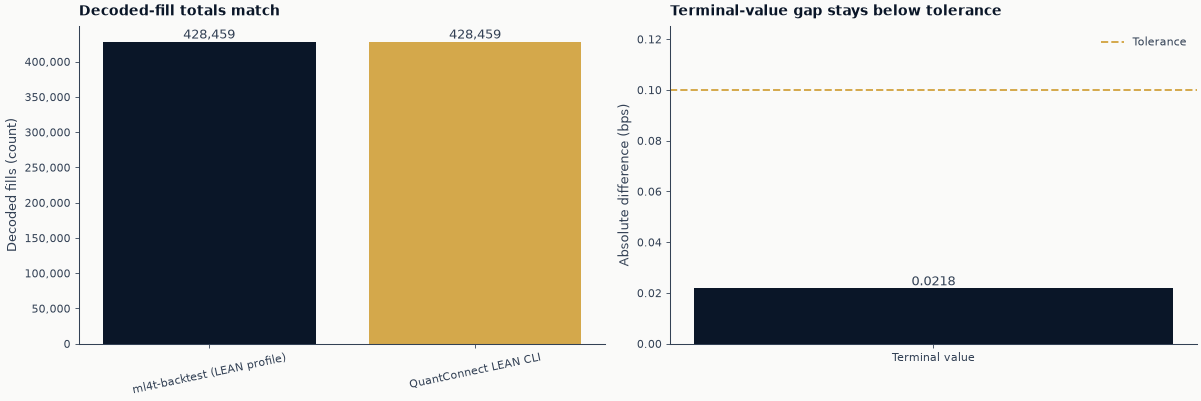

In [17]:
labels = [ml4t_row["label"], lean_row["label"]]
fill_counts = [ml4t_row["decoded_fills"], lean_row["decoded_fills"]]
colors = [COLORS["blue"], COLORS["amber"]]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")
axes[0].bar(labels, fill_counts, color=colors)
axes[0].set_ylabel("Decoded fills (count)")
axes[0].set_ylim(bottom=0)
axes[0].tick_params(axis="x", rotation=12)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:,.0f}"))
for index, count in enumerate(fill_counts):
    axes[0].text(index, count, f"{count:,}", ha="center", va="bottom")
axes[0].set_title(
    "Decoded-fill totals match", loc="left", color=COLORS["blue"], fontweight="bold", pad=8
)

axes[1].bar(["Terminal value"], [metrics["final_value_gap_bps_abs"]], color=COLORS["blue"])
axes[1].axhline(PARITY_TOLERANCE_BPS, color=COLORS["amber"], linestyle="--", label="Tolerance")
axes[1].set_ylabel("Absolute difference (bps)")
axes[1].set_ylim(0, PARITY_TOLERANCE_BPS * 1.25)
axes[1].legend(frameon=False)
axes[1].text(
    0,
    metrics["final_value_gap_bps_abs"],
    f"{metrics['final_value_gap_bps_abs']:.4f}",
    ha="center",
    va="bottom",
)
axes[1].set_title(
    "Terminal-value gap stays below tolerance",
    loc="left",
    color=COLORS["blue"],
    fontweight="bold",
    pad=8,
)

fig.show()

Equal aggregate fill totals do not prove identical timestamps, symbols, quantities, or prices.
Likewise, a terminal-value check can miss offsetting path differences. Event-level chronology and
broader scenario coverage require separate harness diagnostics; this notebook makes neither claim.

## 7. Key Takeaways and Limitations

The synthesis below is generated from the validated rows so its reported values remain aligned
with either the recorded snapshot or a requested live replay.

In [18]:
display(
    Markdown(
        "\n".join(
            [
                f"1. **Aggregate fill parity {'holds' if metrics['fill_gap_abs'] == 0 else 'does not hold'}.** "
                f"The absolute decoded-fill gap is **{metrics['fill_gap_abs']:,}**.",
                f"2. **Terminal-value parity {'passes' if parity_pass else 'fails'}.** The absolute gap is "
                f"**{metrics['final_value_gap_bps_abs']:.4f} bps** against the declared "
                f"**{PARITY_TOLERANCE_BPS:.2f} bps** tolerance.",
                f"3. **Recorded speed is contextual.** This snapshot reports an approximate "
                f"**{metrics['runtime_speedup']:.1f}x** ratio, which is specific to its hardware, "
                "software, cache state, and run date.",
                "4. **The scope is deliberately narrow.** Seeded IID scores, full-window universe "
                "selection, and bidirectional filling make this an execution fixture, not a "
                "point-in-time strategy evaluation.",
                "5. **Endpoint agreement is not chronology identity.** Order-level reconciliation "
                "is required before claiming that every fill event matches.",
            ]
        )
    )
)

1. **Aggregate fill parity holds.** The absolute decoded-fill gap is **0**.
2. **Terminal-value parity passes.** The absolute gap is **0.0218 bps** against the declared **0.10 bps** tolerance.
3. **Recorded speed is contextual.** This snapshot reports an approximate **4.5x** ratio, which is specific to its hardware, software, cache state, and run date.
4. **The scope is deliberately narrow.** Seeded IID scores, full-window universe selection, and bidirectional filling make this an execution fixture, not a point-in-time strategy evaluation.
5. **Endpoint agreement is not chronology identity.** Order-level reconciliation is required before claiming that every fill event matches.

This bounded parity audit supports Chapter 16 Section 16.3 by showing how an external-engine claim
must be tied to explicit comparison surfaces and tolerances.

**Next**: [`17_backtrader_zipline_engine_parity`](17_backtrader_zipline_engine_parity.ipynb)
applies the same discipline to two additional event-driven engines.

---
*Notebook: 15_lean_engine_parity*
*ML4T 3rd Edition - Chapter 16: Strategy Simulation*